<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/Contours_detection_BUSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast cancer
These are images comming from patients
What is breast cancer?
these are Ultra sound image
Why we study ultra sound images?
Clienical chalange --> present the physical images
Distribution in the breast,



Aim for the 3rd project
1. **Train a CNN to detect the mask**
* Yaloo -- CNN type
* A bounding box around the image & put mask
* mask is contorn radiology

After you undrestand what is the imag
2. **After detection**
* Filter the image
3. **Automatically segment(generate contorn)**
Object segmentation
* UNET --> CNN type

4. **Classify delassion into ordintion**


In [ ]:
# Train 3 diffirent model
# 1- model to detect the bounding box(Object detection)
    # * Find the bounding box of the contour--> this is your label for the datast
    # * Split the dataset in trainning and testing dataset

# 2- model to detect the contours
# 3- model to classify(final one) (malignant or benign)

In [1]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import numpy as np
import pandas as pd
import cv2
import torch
import re
from PIL import Image
from torchvision import transforms
from torch import nn
from time import time
import albumentations as A

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
# connect to drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip"

In [ ]:
!unzip /content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip

### Task 1. Read an ultra image with respect column ->
* See the images and the mask
*  white is for boun tesho
* black is for soft tesho of the mask

In [5]:
data_path = ['benign', 'benign_mask', 'malignant', 'malignant_mask']

# check the files and folders
for path in data_path:
  for root, dirs, files in os.walk(path):
    print(f'There are {len(dirs)} directories and  {len(files)} files in "/{root}"')

There are 0 directories and  437 files in "/benign"
There are 0 directories and  455 files in "/benign_mask"
There are 0 directories and  210 files in "/malignant"
There are 0 directories and  212 files in "/malignant_mask"


In [5]:

def extract_idx(filename):
  """
  Extract index from the filename
  """
  index = re.search(r'\((\d+)\)', filename)
  if index is not None:
    return int(index.group(1))
  else: return -1

def is_valid_image(filename, prefix, is_mask=False):
  """
  Make sure the file and the pattern in the dataset match in order to avoid duplicate images
  """
  if is_mask:
    pattern = rf'{prefix} \(\d+\)_mask\.png$'
  else:
      pattern = rf'{prefix} \(\d+\)\.png$'
  return re.match(pattern, filename)

In [6]:
"""
  Clean up the images directories
  read all images in the directory -> extract only images by index in the file -> validate to remove duplicate or invalid image
  sort them based on the index
"""
benign = sorted(
    [f for f in os.listdir('benign') if extract_idx(f) != -1 and is_valid_image(f, 'benign', False)],
    key=extract_idx)
benign_mask = sorted(
    [f for f in os.listdir('benign_mask') if extract_idx(f) != -1 and is_valid_image(f, 'benign', True)],
    key=extract_idx)
malignant = sorted(
    [f for f in os.listdir('malignant') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', False)],
    key=extract_idx)
malignant_mask = sorted(
    [f for f in os.listdir('malignant_mask') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', True)],
    key=extract_idx)

In [ ]:
len(benign), len(benign_mask), len(malignant), len(malignant_mask)

(437, 437, 210, 210)

In [13]:
# plot a random image from each classes
def plot_img_with_mask(depth, root):
  idx = np.random.randint(0, depth)
  fig, ax = plt.subplots(1, 5, figsize=(15, 4))

  # orignal image
  org_img = pltimg.imread(f'{root}/{root} ({idx}).png')
  # mask image
  mask_img = pltimg.imread(f'{root}_mask/{root} ({idx})_mask.png')

  # plot orinal img
  ax[0].imshow(org_img)
  ax[0].set_title(f"Orignal {root} ({idx})")
  ax[0].set_xticks([])
  ax[0].set_yticks([])

  # plot the mask img
  ax[1].imshow(mask_img)
  ax[1].set_title(f"Mask {root} ({idx})")
  ax[1].set_xticks([])
  ax[1].set_yticks([])


  print(f'maks_img shape: {mask_img.shape}')

  # add threshold for the mask image
  if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
    imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask_img

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  # plot the contours image
  contours_img = cv2.drawContours(mask_img, contours, -1, (127,255,0), 2)
  ax[2].imshow(contours_img)
  ax[2].set_title(f"Contours {root} ({idx})")
  ax[2].set_xticks([])
  ax[2].set_yticks([])

  # masked the original image
  controus_img = org_img.copy()
  contours_org_img = cv2.drawContours(controus_img, contours, -1, (127, 255, 0), 2)
  ax[3].imshow(contours_org_img)
  ax[3].set_title(f'Masked {root} ({idx})', color='red')
  ax[3].set_xticks([])
  ax[3].set_yticks([])

  # Contours bounding box
  bound_img = org_img.copy()
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bound_img, (x, y), (x+w, y+h), (0, 255, 0, 0), 4)
  ax[4].imshow(bound_img)
  ax[4].set_title(f'Bounding Contours {root} ({idx})', color='red')
  ax[4].set_xticks([])
  ax[4].set_yticks([])

  plt.tight_layout()


maks_img shape: (396, 600)


maks_img shape: (474, 570)


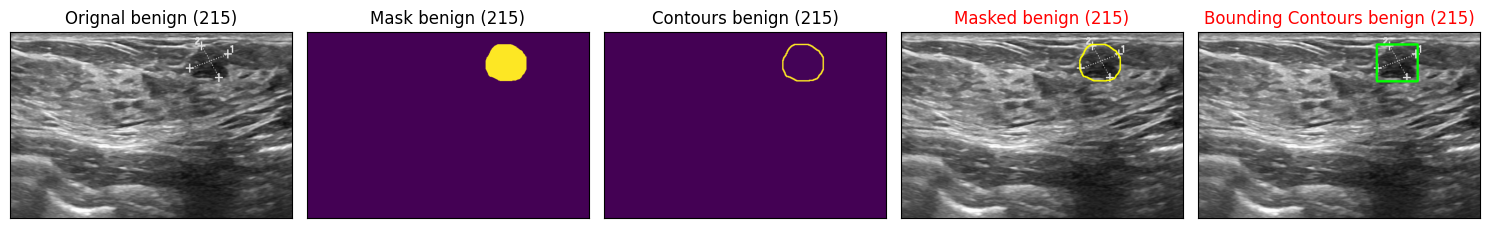

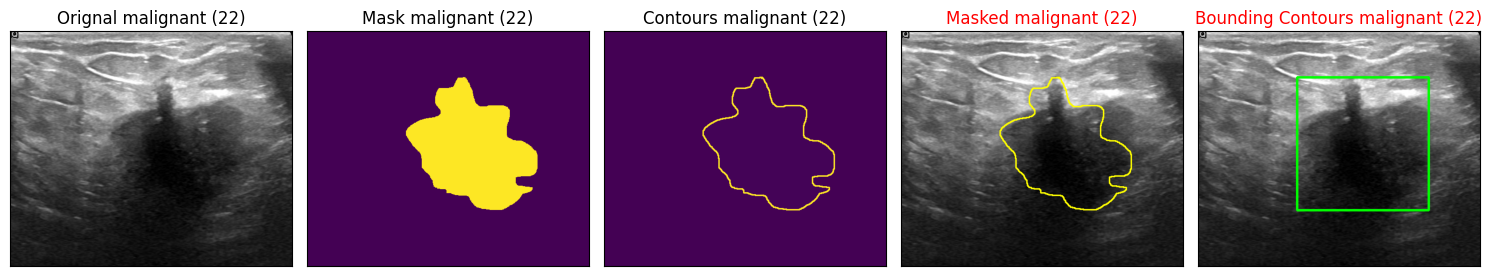

In [14]:
plot_img_with_mask(len(benign), 'benign')
plot_img_with_mask(len(malignant), 'malignant')

222 190 73 59


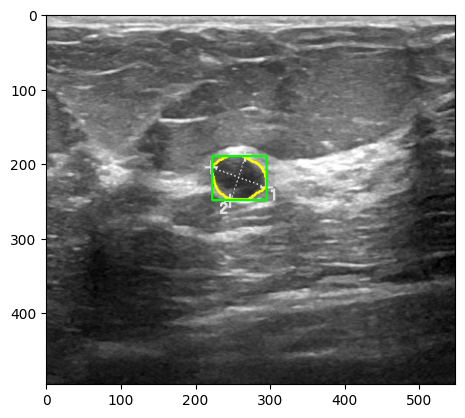

In [ ]:
# add threshold for the mask image
# orignal image
org_img = pltimg.imread(f'benign/benign (5).png')
# mask image
mask_img = pltimg.imread(f'benign_mask/benign (5)_mask.png')

if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
  imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
else:
  imgray = mask_img

imgray = (imgray * 255).astype("uint8") # <-- change image type
_, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours_org_img = cv2.drawContours(org_img, contours, -1, (127, 255, 0), 2)
for cnt in contours:
  x, y, w, h = cv2.boundingRect(cnt)
  print(x, y, w, h)
  cv2.rectangle(contours_org_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(contours_org_img)


In [7]:
def denormalize(img):
    if isinstance(img, torch.Tensor):
        mean = torch.tensor([0.485, 0.456, 0.406], device=img.device)
        std = torch.tensor([0.229, 0.224, 0.225], device=img.device)
        return img * std[:, None, None] + mean[:, None, None]

    elif isinstance(img, np.ndarray):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        return img * std[None, None, :] + mean[None, None, :]

In [8]:
def get_bbox_and_cnt(mask):
  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

  # get the contours
  contours, _ = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours)==0:
    return None

  # take the largest contour
  cnt = max(contours, key=cv2.contourArea)
  # get the bounding box
  x, y, w, h = cv2.boundingRect(cnt)

  return contours, [x, y, w, h]


In [9]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, img_list, mask_list, img_dir, mask_dir, transform = None, image_size = 224):
    self.img_list = img_list
    self.mask_list = mask_list
    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.image_size = image_size

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    image_path = os.path.join(self.img_dir, self.img_list[index])
    mask_path = os.path.join(self.mask_dir, self.mask_list[index])

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    image = np.array(image)
    mask = np.array(mask).astype(np.float32)/255.

    if self.transform:
      result = self.transform(image=image, mask=mask)
      image = result['image']
      mask = result['mask']
    return image.float(), mask.float()


In [10]:
# Create a Augmentation Pipeline
img_size = 300
transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),

    # Geometric
    A.HorizontalFlip(p=0.1),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=5,
        p=0.1
    ),

    # Light intensity changes
    A.RandomBrightnessContrast(p=0.1),

    # Optional (low probability)
    A.GaussNoise(std_range=(0.1, 0.2), p=0.1),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] ),
    A.pytorch.ToTensorV2(),
])

benign_dataset = Dataset(benign, benign_mask, 'benign', 'benign_mask', transform=transform_pipeline, image_size=img_size)
malignant_dataset = Dataset(malignant, malignant_mask, 'malignant', 'malignant_mask', transform=transform_pipeline)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


((300, 300, 3), torch.Size([300, 300]))

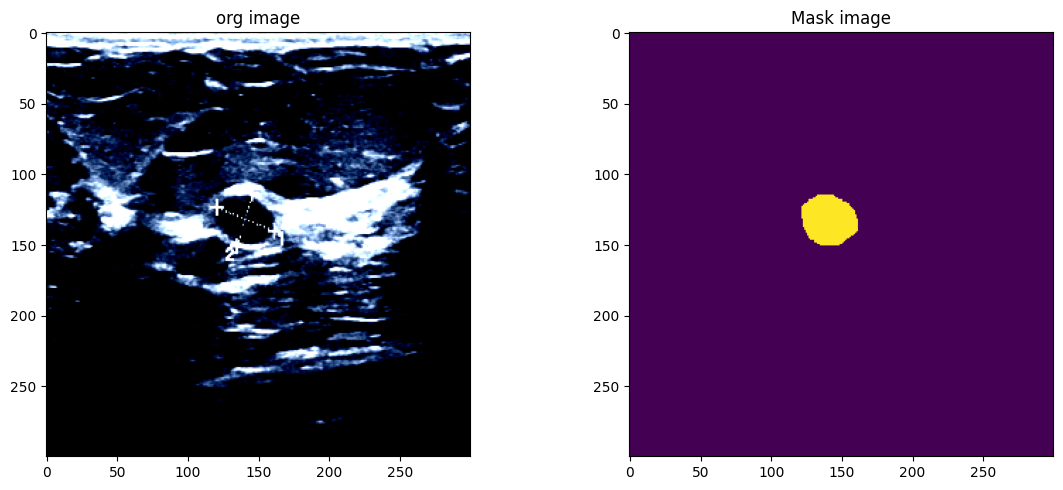

In [11]:
img, label = benign_dataset.__getitem__(4)
img = img.permute(1,2,0).cpu().numpy()
_, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title("org image")

ax[1].imshow(label)
ax[1].set_title("Mask image")

plt.tight_layout()

img.shape, label.shape

In [ ]:
len(benign_dataset)

437

In [12]:
start_time = time()
save_dir = "data"
# create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)
for i in range(len(benign_dataset)):
    image, bbox = benign_dataset[i]   # <-- NOW data is loaded

    torch.save((image, bbox), f"{save_dir}/benign_{i}.pt", )
print(f'tokes {time()-start_time}s')

tokes 18.767786264419556s


In [13]:
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        self.files = os.listdir(data_dir)
        self.data_dir = data_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.files[idx])
        image, bbox = torch.load(path, weights_only=False)
        return image, bbox

In [14]:
cached_dataset = CachedDataset("data")
len(cached_dataset)

437

In [74]:
img, label = cached_dataset.__getitem__(0)
img.shape, label.shape

(torch.Size([3, 300, 300]), torch.Size([300, 300]))

In [15]:
# splitting the Benign to training and testing
train_size = int(0.7 * len(cached_dataset)) # 70%
valid_size = int(0.2 * len(cached_dataset)) # 20%
test_size = len(cached_dataset)-train_size-valid_size # 10%
ben_train_dataset, ben_valid_dataset, ben_test_dataset = torch.utils.data.random_split(cached_dataset, [train_size, valid_size, test_size])

In [76]:
len(ben_train_dataset), len(ben_valid_dataset), len(ben_test_dataset)

(305, 87, 45)

In [16]:
# add data loader
ben_train_loader = torch.utils.data.DataLoader(dataset=ben_train_dataset, batch_size=16, num_workers=2, shuffle=True, drop_last=True)
ben_valid_loader = torch.utils.data.DataLoader(dataset=ben_valid_dataset, batch_size=16, num_workers=2, shuffle=True)
ben_test_loader = torch.utils.data.DataLoader(dataset=ben_test_dataset, batch_size=16, num_workers=2, shuffle=False)

In [ ]:
img.shape,

((300, 300, 3),)

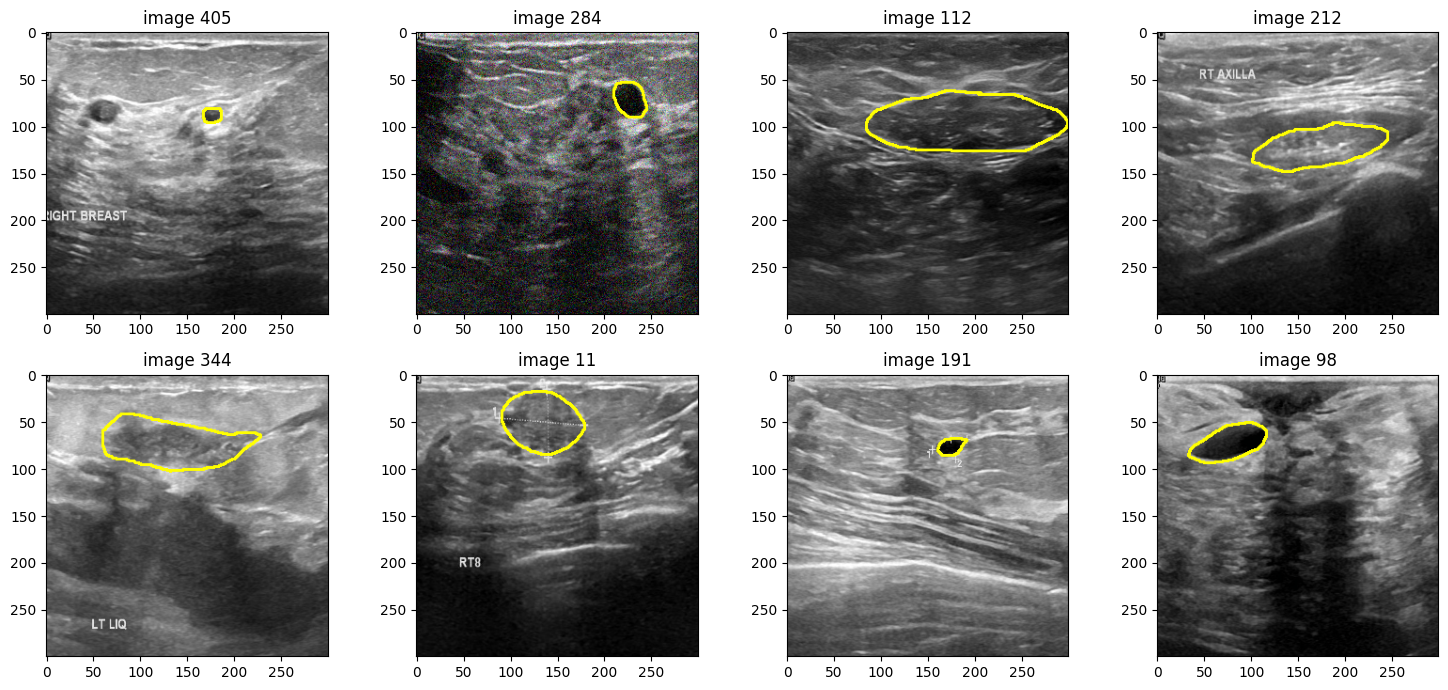

In [128]:
# plot some augmented images with mask
plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(len(ben_test_dataset.dataset))
  img, mask = ben_test_loader.dataset.dataset.__getitem__(idx)

  img = denormalize(img.permute(1,2,0).cpu().numpy())
  plt.subplot(2, 4, i+1)

  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = np.array(mask)

  if imgray.max() <= 1:
      imgray = (imgray * 255).astype("uint8")
  else:
      imgray = imgray.astype("uint8")
  mask = denormalize(mask)
  _, threshold = cv2.threshold(imgray.copy(), 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  contours_org_img = cv2.drawContours(img, contours, -1, (127, 255, 0), 2)

  plt.imshow(contours_org_img)
  plt.title(f"image {idx}")
plt.tight_layout()


In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=2):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, stride=stride),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )

        # match dimensions for skip connection
        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_c)
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.skip(x)      # original path

        out = self.conv(x)           # transformed path

        out = out + residual
        out = self.relu(out)  #  RESIDUAL ADDED

        return out

**ResNet Encoder + U-Net Decoder (ResUNet)**
```
Input → Encoder (ResBlocks ↓) → Bottleneck
      → Decoder (↑ + Skip connections) → Output Mask
```

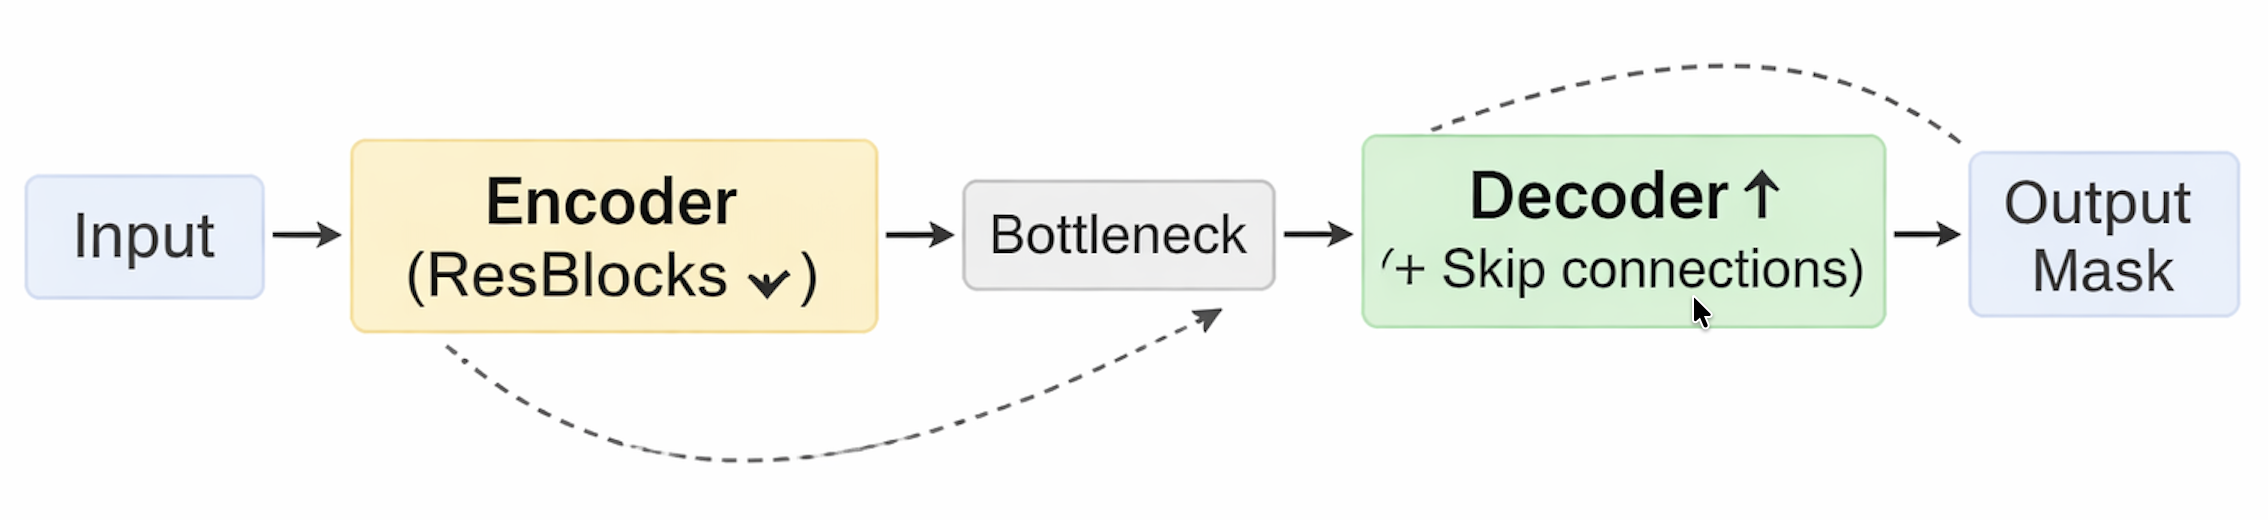

In [95]:
# Builing the network
class Cnn_network(nn.Module):
  def __init__(self, num_class):
    super(Cnn_network, self).__init__()

    # Encoder
    self.block1 = nn.Sequential(
        ResidualBlock(3, 32, stride=2),
        ResidualBlock(32, 32, stride=1)
    )

    self.block2 = nn.Sequential(
        ResidualBlock(32, 64, stride=2),
        ResidualBlock(64, 64, stride=1)
    )

    self.block3 = nn.Sequential(
        ResidualBlock(64, 128, stride=2),
        ResidualBlock(128, 128, stride=1)
    )

    self.block4 = nn.Sequential(
        ResidualBlock(128, 256, stride=2),
        ResidualBlock(256, 256, stride=1)
    )

    # Decoder
    self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
    self.up4 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)

    self.conv1 = ResidualBlock(256, 128, stride=1)
    self.conv2 = ResidualBlock(128, 64, stride=1)
    self.conv3 = ResidualBlock(64, 32, stride=1)
    self.conv4 = ResidualBlock(32, 32, stride=1)


    self.final = nn.Conv2d(32, 1, kernel_size=1)


  def forward(self, x):

    # Encoder
    x1 = self.block1(x)
    x2 = self.block2(x1)
    x3 = self.block3(x2)
    x4 = self.block4(x3)

    # Decoder
    x = self.up1(x4)
    x = nn.functional.interpolate(x, size=x3.shape[2:])
    x = torch.cat([x, x3], dim=1)
    x = self.conv1(x)

    x = self.up2(x)
    x = nn.functional.interpolate(x, size=x2.shape[2:])
    x = torch.cat([x, x2], dim=1)
    x = self.conv2(x)

    x = self.up3(x)
    x = nn.functional.interpolate(x, size=x1.shape[2:])
    x = torch.cat([x, x1], dim=1)
    x = self.conv3(x)

    x = self.up4(x)
    x = self.conv4(x)

    x = self.final(x)
    return x
net = Cnn_network(4).to(device)
net

Cnn_network(
  (block1): Sequential(
    (0): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     

In [ ]:
# test the model
dumy_dataset = torch.randn(2, 3, 300, 300).to(device)
# test the model
pred = net(dumy_dataset)
pred

In [131]:
# define the compiler
optimizer = torch.optim.AdamW(params=net.parameters(), lr=0.0005, weight_decay=0.0001)
# ↑ (Adam with Weight Decay) decouples these, leading to better generalization more consistant decay

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, # Drops the learning rate when the validation loss stops improving
                                                       mode='min',
                                                       patience=3,
                                                       factor=0.5)
loss_fun = torch.nn.BCEWithLogitsLoss()

In [132]:
# training method
def train(data_loader, loss_fun, optimizer):
  # print(f'is training: {net.training}')
  size = len(data_loader.dataset)
  training_loss = 0
  number_of_batches = len(data_loader)

  net.train(mode=True) # set the model in the training mode
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y = y.unsqueeze(1).float()
    # reset all the gradient
    optimizer.zero_grad()

    output = net(X) # <-- directly calling the forward method
    loss = loss_fun(output, y) # calculate the error
    # print(f"loss: {loss} output: {output.shape}")
    loss.backward() # compute the gradient
    # at this point we computed the gradient

    optimizer.step() # update the weights
    training_loss += loss.item()
    if (batch+1 == number_of_batches):
      print(f'Batch {batch+1}/{number_of_batches} | Loss: {loss.item():.4f}')

  return training_loss/number_of_batches


In [133]:
# Validate the model
def val_model(data_loader, loss_fun):
  val_loss = 0
  net.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)
      y = y.unsqueeze(1).float()

      output = net(X)

      loss = loss_fun(output, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [37]:
img, label = ben_train_loader.dataset.dataset.__getitem__(0)
img.shape

torch.Size([3, 300, 300])

In [134]:
epoch = 15
history = {'tr_loss': [], 'val_loss': []}
for i in range(epoch):
  print(f"Epoch {i}: ")
  tr_loss = train(ben_train_loader, loss_fun, optimizer)
  history['tr_loss'].append(tr_loss)
  avg_loss = val_model(ben_valid_loader, loss_fun)

  # update the learning rate
  scheduler.step(avg_loss)
  history['val_loss'].append(avg_loss)
  print(f"Validation loss: {avg_loss}")

Epoch 0: 
Batch 19/19 | Loss: 0.4174
Validation loss: 0.5216324826081594
Epoch 1: 
Batch 19/19 | Loss: 0.3640
Validation loss: 0.3407107541958491
Epoch 2: 
Batch 19/19 | Loss: 0.2570
Validation loss: 0.2587815448641777
Epoch 3: 
Batch 19/19 | Loss: 0.2167
Validation loss: 0.23241423070430756
Epoch 4: 
Batch 19/19 | Loss: 0.1670
Validation loss: 0.23821968336900076
Epoch 5: 
Batch 19/19 | Loss: 0.1619
Validation loss: 0.19285675138235092
Epoch 6: 
Batch 19/19 | Loss: 0.1394
Validation loss: 0.20259892692168555
Epoch 7: 
Batch 19/19 | Loss: 0.1638
Validation loss: 0.17272898803154627
Epoch 8: 
Batch 19/19 | Loss: 0.0860
Validation loss: 0.16593037048975626
Epoch 9: 
Batch 19/19 | Loss: 0.1441
Validation loss: 0.1553269810974598
Epoch 10: 
Batch 19/19 | Loss: 0.0731
Validation loss: 0.14859691138068834
Epoch 11: 
Batch 19/19 | Loss: 0.0876
Validation loss: 0.15434605876604715
Epoch 12: 
Batch 19/19 | Loss: 0.1409
Validation loss: 0.1466214656829834
Epoch 13: 
Batch 19/19 | Loss: 0.0649
Va

<Axes: >

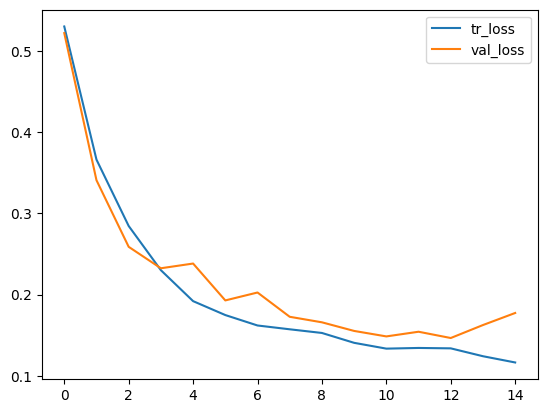

In [135]:
# Plot the loss curve
pd.DataFrame(history).plot()

In [19]:
model_path = '/content/drive/MyDrive/Healthcare/BUSI/mask1.pt'

In [152]:
# save the model
torch.save(net.state_dict(), model_path)

In [20]:
# load the model
model = Cnn_network(num_class=4).to(device)

state_dict = torch.load(model_path, weights_only=True, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

model.eval()

Cnn_network(
  (block1): Sequential(
    (0): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     

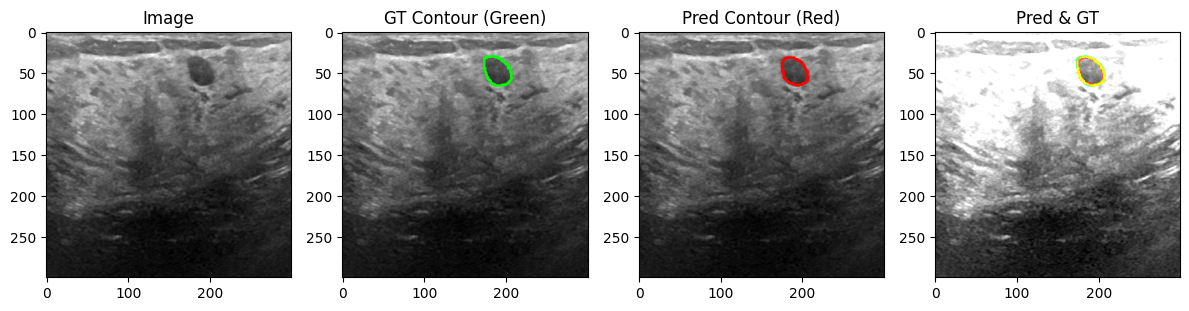

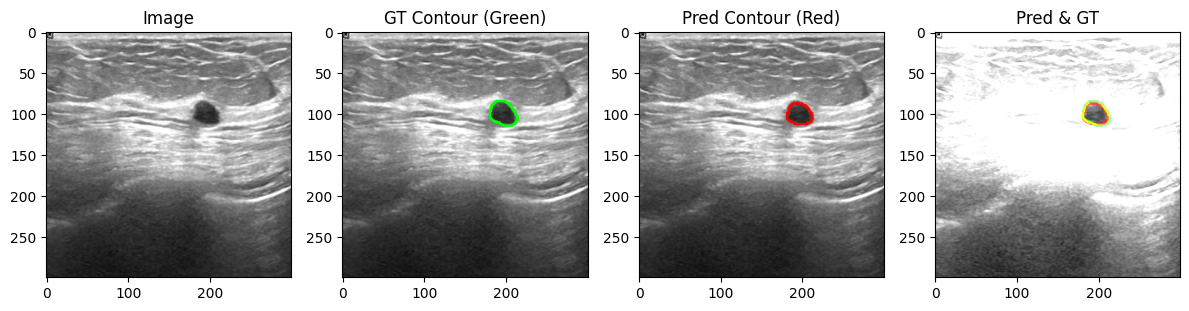

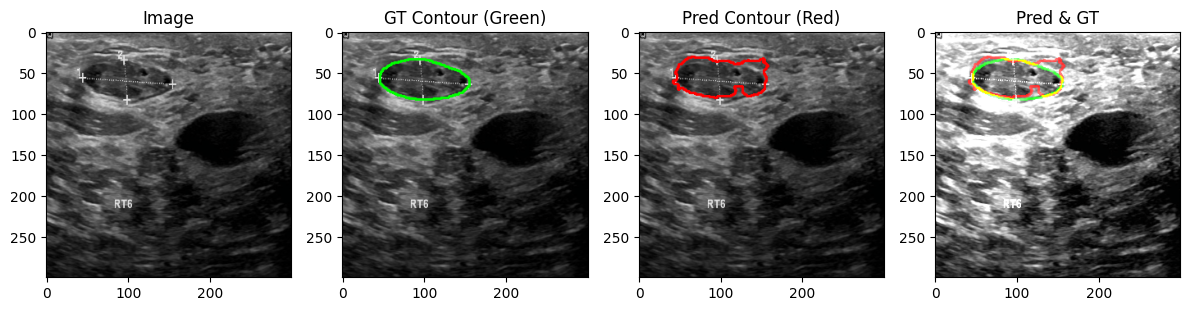

In [94]:
for _ in range(3):
  idx = np.random.randint(len(ben_test_dataset))
  img, gt_mask = ben_test_dataset[idx]

  with torch.no_grad():
      pred = model(img.unsqueeze(0).to(device))
      pred = torch.sigmoid(pred).squeeze().cpu().numpy()

  # image for display
  img_vis = denormalize(img.permute(1,2,0).cpu().numpy()).copy()

  # convert masks to binary uint8
  pred_mask = (pred > 0.5).astype(np.uint8)
  gt_mask = gt_mask.squeeze().cpu().numpy().astype(np.uint8)

  # ensure uint8
  pred_mask = (pred_mask * 255).astype(np.uint8)
  gt_mask = (gt_mask * 255).astype(np.uint8)

  # find contours
  pred_contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  gt_contours, _ = cv2.findContours(gt_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  # draw on image
  img_pred = img_vis.copy()
  img_gt = img_vis.copy()

  cv2.drawContours(img_pred, pred_contours, -1, (255, 0, 0), 2)  # RED = prediction
  cv2.drawContours(img_gt, gt_contours, -1, (0, 255, 0), 2)      # GREEN = GT

  # plot
  plt.figure(figsize=(12,8))

  plt.subplot(1,4,1)
  plt.imshow(img_vis)
  plt.title("Image")

  plt.subplot(1,4,2)
  plt.imshow(img_gt)
  plt.title("GT Contour (Green)")

  plt.subplot(1,4,3)
  plt.imshow(img_pred)
  plt.title("Pred Contour (Red)")

  plt.subplot(1,4,4)
  plt.imshow(img_pred+img_gt)
  plt.title("Pred & GT")

  plt.tight_layout()
  plt.show()